<a href="https://colab.research.google.com/github/akimotolab/CMAES_Tutorial/blob/main/p2_formulation_and_difficult_problems.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 謝辞


本ノートブックは，日本船舶海洋工学会の主催する第３５４回KFRセミナー「船舶海洋工学者のためのブラックボックス最適化セミナー」にて使用するために取りまとめたものである．以前よりこのような実践ガイドを作成して公開したいと思っていたが，今回のような機会がなかったらいつまでも完成させられずにいたと思う．本セミナーを企画し，今回のような機会を与えてくれた大阪大学の牧敦生先生には深く感謝する．また，第３５４回KFRセミナーにて講演頂いた大阪大学（講演当時博士課程在籍中）の宮内新喜氏からは，CMA-ESの船舶海洋工学分野への応用に関する共同研究や，今回の宮内氏の講演資料を通して，数多くの知見を得ることができた．ここで得られた知見は，応用研究に携わっている研究者であるからこそ得られるものであり，共同研究がなければ得られなかったことと思う．牧先生と宮内氏の両名には深く感謝する．

<!-- EN -->
# Acknowledgment


<!-- EN -->

This notebook was compiled for use at the 354th KFR Seminar, "Black-Box Optimization Seminar for Naval Architects and Ocean Engineers," organized by the Japan Society of Naval Architects and Ocean Engineers. I had long wanted to create and publish such a practical guide, but I suspect it would never have been completed without an opportunity like this one. I am deeply grateful to Professor Atsuo Maki of Osaka University for organizing the seminar and giving me this opportunity. I also received many valuable insights from Mr. Yoshiki Miyauchi (then a doctoral student at Osaka University) who presented at the 354th KFR Seminar, through our joint research on the application of CMA-ES to the field of naval architecture and ocean engineering and through his lecture materials. The insights gained there are ones that could only be obtained by a researcher engaged in applied research, and I do not think they could have been obtained without that collaboration. I am deeply grateful to both Professor Maki and Mr. Miyauchi.


# 目的

勾配を用いない最適化法であるCMA-ESを利用している応用側の研究者から，「CMA-ESを用いてみたが，望ましい解が得られない」といった相談やコメントをしばしばいただきます．ここでは，CMA-ESをうまく活用するための設定，実験結果から問題の性質についての分析，問題定式化の検討の観点から，私の経験則をまとめます．

<!-- EN -->
# Purpose


<!-- EN -->
Applied researchers who use CMA-ES, a gradient-free optimization method, often ask or comment that "we tried CMA-ES but could not obtain a satisfactory solution." Here, I summarize my empirical rules from the perspectives of settings for making effective use of CMA-ES, analysis of problem characteristics from experimental results, and reconsideration of problem formulation.


# 参考資料

この資料は，著者らが毎年国際会議GECCOにおいて開催しているCMA-ESチュートリアルを参考にしています．以下のチュートリアルではCMA-ESの設計原理やアルゴリズムの各コンポーネントの役割を中心に解説しています．一方，本資料では，CMA-ESをうまく活用するための方法に焦点を当てています．

Youhei Akimoto and Nikolaus Hansen. 2022. CMA-ES and advanced adaptation mechanisms. In Proceedings of the Genetic and Evolutionary Computation Conference Companion (GECCO '22). Association for Computing Machinery, New York, NY, USA, 1243–1268. https://doi.org/10.1145/3520304.3533648
チュートリアル動画：https://www.youtube.com/watch?v=7VBKLH3oDuw






<!-- EN -->
# References


<!-- EN -->
This material is based on the CMA-ES tutorial that the authors have held annually at the international conference GECCO. The following tutorial focuses on the design principles of CMA-ES and the role of each component of the algorithm. This material, on the other hand, focuses on methods for making effective use of CMA-ES.

Youhei Akimoto and Nikolaus Hansen. 2022. CMA-ES and advanced adaptation mechanisms. In Proceedings of the Genetic and Evolutionary Computation Conference Companion (GECCO '22). Association for Computing Machinery, New York, NY, USA, 1243–1268. https://doi.org/10.1145/3520304.3533648
Tutorial video: https://www.youtube.com/watch?v=7VBKLH3oDuw


# プログラム

このチュートリアルでは，著者らが公開している最新のCMA-ESの実装である，DD-CMA-ESを用いています．

Y. Akimoto and N. Hansen.
    Diagonal Acceleration for Covariance Matrix Adaptation Evolution Strategies
    Evolutionary Computation (2020) 28(3): 405--435.
コード：https://gist.github.com/youheiakimoto/1180b67b5a0b1265c204cba991fa8518

<!-- EN -->
# Program


<!-- EN -->
In this tutorial, we use DD-CMA-ES, the authors' latest publicly available implementation of CMA-ES.

Y. Akimoto and N. Hansen.
    Diagonal Acceleration for Covariance Matrix Adaptation Evolution Strategies
    Evolutionary Computation (2020) 28(3): 405--435.
Code: https://gist.github.com/youheiakimoto/1180b67b5a0b1265c204cba991fa8518


以下はDD-CMA-ESのアルゴリズムに，矩形制約対処法，周期変数の扱い，リスタート戦略を追加実装したものです．

<!-- EN -->
The following is an implementation that adds box-constraint handling, periodic variable treatment, and a restart strategy to the DD-CMA-ES algorithm.


In [1]:
!wget https://gist.githubusercontent.com/youheiakimoto/1180b67b5a0b1265c204cba991fa8518/raw/8f3ad2b554680a0c9888904ec2e609e63554a140/ddcma.py
%run ddcma.py

--2026-09-02 14:09:13--  https://gist.githubusercontent.com/youheiakimoto/1180b67b5a0b1265c204cba991fa8518/raw/8f3ad2b554680a0c9888904ec2e609e63554a140/ddcma.py
Resolving gist.githubusercontent.com (gist.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to gist.githubusercontent.com (gist.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 27127 (26K) [text/plain]
Saving to: ‘ddcma.py’

ddcma.py            100%[===================>]  26.49K  --.-KB/s    in 0.002s  

2026-09-02 14:09:13 (13.2 MB/s) - ‘ddcma.py’ saved [27127/27127]

10 100 1836452438.816659 1836452438.816659
20 200 265026141.33530036 265026141.33530036
30 300 355111236.1944697 148752348.95533752
40 400 148442069.54024994 46875873.46476235
50 500 66584893.38373168 46875873.46476235
60 600 32404291.860606946 32404291.860606946
70 700 4667246.438295592 4667246.438295592
80 800 1965135.2099439306 1452364.6899801418
90 900 7

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# 定式化の見直し



最適化を実行してみたが望ましい解が得られない，という場面は多々あると思います．まず前項目までにみた検討項目について，十分な回数のリスタートがなされているのか，適切な終了条件が設定されているのか，初期分布パラメータは適切か，など，再度確認してみましょう．それでもうまく行かない場合，最適化問題の定式化を再検討することが必要になります．その際，分布パラメータの推移（上で出力しているような図）も確認しましょう．その中に，うまく解くためのヒントが隠されている場合があります．

ここでは，実際に起こりがちな，CMA-ESにとって解きにくい目的関数の設計と，そのときのCMA-ESの振る舞いをいくつか紹介します．

1. ほとんど平らな多峰性の目的関数 or 周期関数
2. 目的関数に影響を与えない変数
3. 尖った等高線を持つ目的関数
4. 大域的多峰な目的関数

<!-- EN -->
# Revisiting the Problem Formulation


<!-- EN -->

There are many cases where a satisfactory solution cannot be obtained after running optimization. First, re-examine the items considered in the previous sections: whether a sufficient number of restarts have been performed, whether appropriate stopping criteria are set, whether the initial distribution parameters are appropriate, and so forth. If things still do not work well, it becomes necessary to reconsider the formulation of the optimization problem. At that time, also check the history of the distribution parameters (figures such as those output above). Hints for solving the problem well may be hidden there.

Here, we introduce several practically common objective function designs that are difficult for CMA-ES to solve, and the behavior of CMA-ES in those cases.

1. Nearly flat multimodal objective functions or periodic functions
2. Variables that have no effect on the objective function
3. Objective functions with sharp contours
4. Globally multimodal objective functions


## 1. ほとんど平らな多峰性の目的関数 or 周期関数


CMA-ESは目的関数の値を直接用いず，複数の解のランキングに基づいて探索をしていきます．そのため，どれだけ勾配が小さくても，解の優越が正しく決定できる限り，勾配の小さな問題でも全く問題なく最適化ができます．例えば，
$$
f(x) = \sum_{i=1}^{d} x_i^2
$$
と
$$
f(x) = 20 - 20 \exp\left(-0.2 \sqrt{\frac{1}{d}\sum_{i=1}^{d} x_i^2}\right)
$$
は，単調増加変換の関係にあるため，CMA-ESからは等価な関数であるように扱われます．これは，目的関数のスケーリングを考慮しなくて良い，という観点で望ましい性質の一つです．

ただし，ここに多峰性が含まれると，注意すべき状況が発生します．例えば，上の関数に周期関数を加えた Ackley関数
$$
f(x) = 20 - 20 \exp\left(-0.2 \sqrt{\frac{1}{d}\sum_{i=1}^{d} x_i^2}\right) + \exp(1) - \exp\left(\frac{1}{d}\sum_{i=1}^{d} \cos(2\pi x_i)\right)
$$
を考えましょう．局所解は複数存在しますが，探索領域が$[-30, 30]^d$程度に制限されている場合，この関数はCMA-ESにとって，最適解$x^* = 0$を比較的容易に発見できる関数です．しかし，その探索領域が制限されていない場合，$[-30, 30]^d$の外側では追加された項$\exp(1) - \exp\left(\frac{1}{d}\sum_{i=1}^{d} \cos(2\pi x_i)\right)$が支配的になります．この場合，CMA-ESからみれば，ほとんど周期関数を複数の周期に渡って最適化しているように見えます．周期関数を複数周期に渡って探索しようとした場合，挙動が不安定になる場合があります．

#### 確認事項
以下，Ackley関数を，と，探索領域を設けて最適化した場合の比較です．
- 探索領域を設けずに最適化した場合（初期ステップサイズを30と比較的大きめに設定），$\sigma  D$ の値が以上に大きな値となり，収束できないか非常に効率が悪いこと
- 制約条件を設けることで，不安定な振る舞いを回避できること



<!-- EN -->
## 1. Nearly Flat Multimodal Objective Functions or Periodic Functions


<!-- EN -->

CMA-ES does not use objective function values directly; it searches based on the ranking of multiple solutions. Therefore, no matter how small the gradient is, as long as the dominance between solutions can be correctly determined, optimization can be performed without any problem even for problems with small gradients. For example,
$$
f(x) = \sum_{i=1}^{d} x_i^2
$$
and
$$
f(x) = 20 - 20 \exp\left(-0.2 \sqrt{\frac{1}{d}\sum_{i=1}^{d} x_i^2}\right)
$$
are related by a monotonically increasing transformation, so they are treated as equivalent functions by CMA-ES. This is one of the desirable properties in the sense that the scaling of the objective function does not need to be considered.

However, when multimodality is included here, a situation requiring care arises. For example, consider the Ackley function, which adds a periodic function to the above function:
$$
f(x) = 20 - 20 \exp\left(-0.2 \sqrt{\frac{1}{d}\sum_{i=1}^{d} x_i^2}\right) + \exp(1) - \exp\left(\frac{1}{d}\sum_{i=1}^{d} \cos(2\pi x_i)\right)
$$
Multiple local optima exist, but when the search domain is restricted to approximately $[-30, 30]^d$, this function is one for which CMA-ES can find the optimal solution $x^* = 0$ relatively easily. However, when the search domain is not restricted, outside of $[-30, 30]^d$, the added term $\exp(1) - \exp\left(\frac{1}{d}\sum_{i=1}^{d} \cos(2\pi x_i)\right)$ becomes dominant. In that case, from CMA-ES's perspective, it appears almost as if it is optimizing a periodic function over multiple periods. When attempting to search a periodic function over multiple periods, the behavior may become unstable.

#### Items to verify
The following compares optimization of the Ackley function with and without a search domain constraint.
- When optimizing without a search domain constraint (initial step size set to 30, relatively large), the values of $\sigma D$ become abnormally large, and convergence cannot be achieved or is very inefficient.
- Adding constraints avoids the unstable behavior.


10 100 20.040497180230542 18.1376248731887
20 200 20.1630119446076 18.1376248731887
30 300 20.458204682170997 17.02627565371547
40 400 19.857454453924746 17.02627565371547
50 500 17.902517563075065 15.91813587498243
60 600 11.842761202388468 11.434174279923393
70 700 7.556931877414538 7.556931877414538
80 800 5.8487330697463324 5.77456914455594
90 900 3.5354589861579684 3.5354589861579684
100 1000 2.690108041218193 1.8572395037149931
110 1100 1.1980346004832345 1.1980346004832345
120 1200 0.8755762812456704 0.7834779972185624
130 1300 0.34618329237272594 0.3183702833545734
140 1400 0.16484138582914465 0.1270718830919959
150 1500 0.04253441442117456 0.04253441442117456
160 1600 0.026530581272071974 0.026516011758698443
170 1700 0.014121815797130122 0.011404702910215114
180 1800 0.004732363702639297 0.004732363702639297
190 1900 0.003347053787821963 0.003347053787821963
200 2000 0.0017901835885605344 0.0017901835885605344
210 2100 0.0009366913432753421 0.0005580773298947683
220 2200 0.00

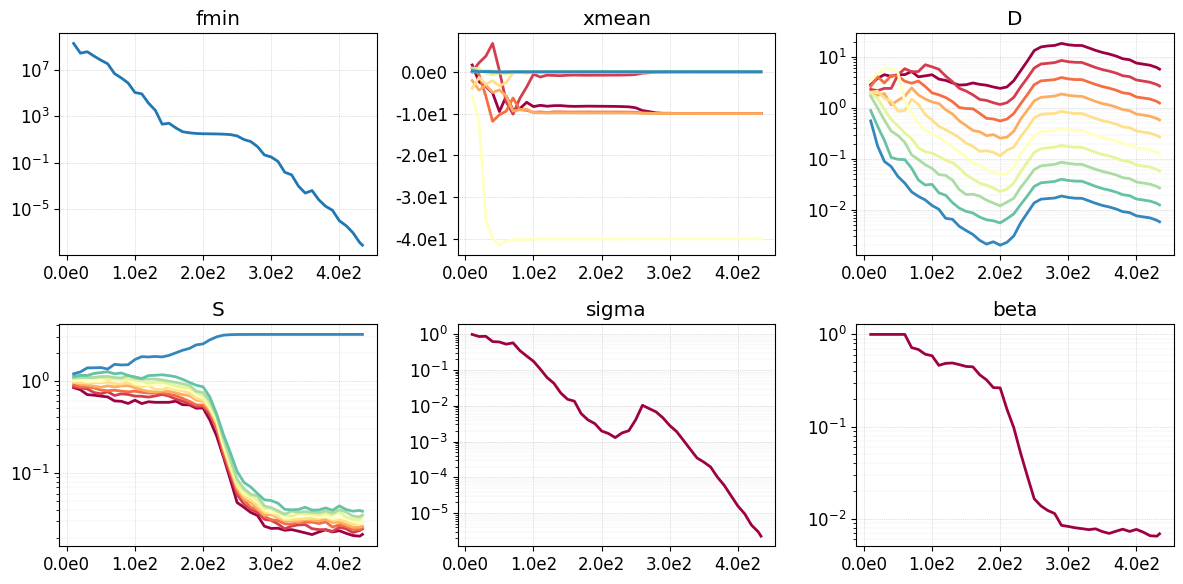

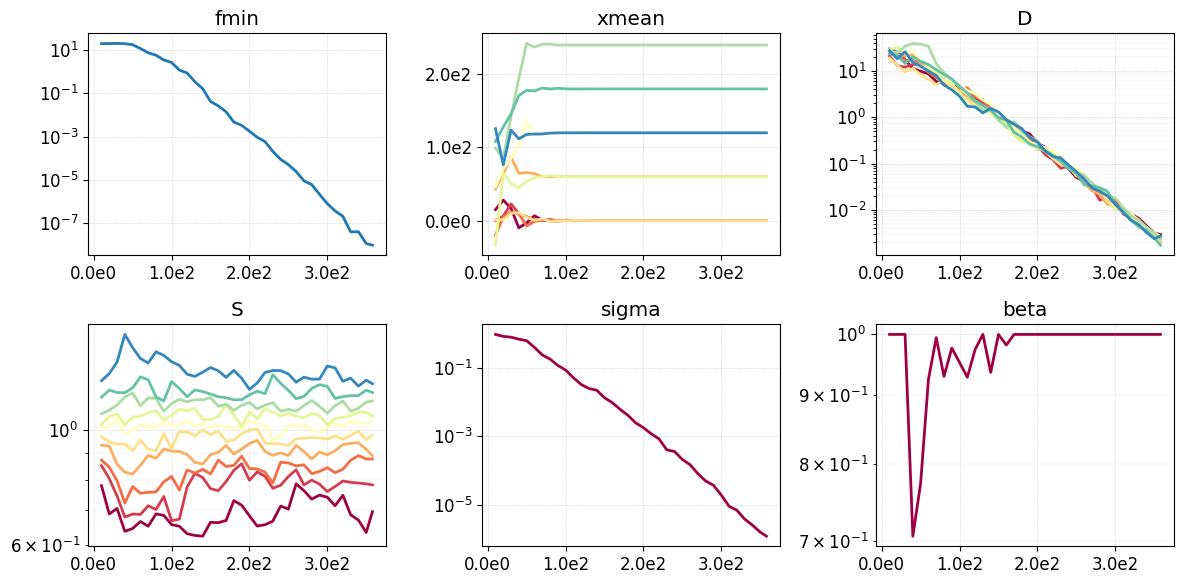

In [3]:
# 実行スクリプト
# Ellipsoid-Cigar function
N = 10
xmean0 = 30 * np.random.rand(N)  # 恣意的に最適解からずらして初期化
D0 = 30 * np.ones(N)  # 探索領域の幅の1/4
def ackley(x):
    a = 20
    b = 0.2
    c = 2 * np.pi
    f1 = a * (1 - np.exp(-b*np.sqrt(np.mean(x**2, axis=1))))
    f2 = np.exp(1) - np.exp(np.mean(np.cos(c * x), axis=1))
    return f1 + f2

# Support for box constraint and periodic variables
# Set np.nan, -np.inf or np.inf if no bound
if False:
    # 制約条件を考慮しない場合
    LOWER_BOUND = -np.inf * np.ones(N)
    UPPER_BOUND = np.inf * np.ones(N)
else:
    # 制約条件を考慮する場合
    LOWER_BOUND = -30.0 * np.ones(N)
    UPPER_BOUND = 30.0 * np.ones(N)
FLAG_PERIODIC = np.asarray([False] * N)
period_length = (UPPER_BOUND - LOWER_BOUND) * 2.0
period_length[FLAG_PERIODIC] /= 2.0
period_length[np.logical_not(np.isfinite(period_length))] = np.inf

def fobj(x):
    xx = mirror(x, LOWER_BOUND, UPPER_BOUND, FLAG_PERIODIC)
    return ackley(xx)

# Setting for resart
NUM_RESTART = 10  # number of restarts with increased population size
MAX_NEVAL = 1e6   # maximal number of f-calls
F_TARGET = 1e-8   # target function value
total_neval = 0   # total number of f-calls

# Main loop
ddcma = DdCma(xmean0=xmean0, sigma0=D0)
ddcma.upper_bounding_coordinate_std(period_length)
checker = Checker(ddcma)
logger = Logger(ddcma)
for restart in range(NUM_RESTART):
    issatisfied = False
    fbestsofar = np.inf
    while not issatisfied:
        ddcma.onestep(func=fobj)
        ddcma.upper_bounding_coordinate_std(period_length)
        fbest = np.min(ddcma.arf)
        fbestsofar = min(fbest, fbestsofar)
        if fbest <= F_TARGET:
            issatisfied, condition = True, 'ftarget'
        else:
            issatisfied, condition = checker()
        if ddcma.t % 10 == 0:
            print(ddcma.t, ddcma.neval, fbest, fbestsofar)
            logger()
    logger(condition)
    print("Terminated with condition: " + str(condition))
    # For restart
    total_neval += ddcma.neval
    if total_neval < MAX_NEVAL and fbest > F_TARGET and restart + 1 < NUM_RESTART:
        popsize = ddcma.lam * 2
        xmean0 = 30 * np.random.rand(N)  # 恣意的に最適解からずらして初期化
        D0 = 15 * np.ones(N)  # 探索領域の幅の1/4
        ddcma = DdCma(xmean0=xmean0, sigma0=D0, lam=popsize)
        checker = Checker(ddcma)
        logger.setcma(ddcma)
        print("Restart with popsize: " + str(ddcma.lam))
    else:
        break

# Produce a figure
fig, axdict = logger.plot()
for key in axdict:
    if key not in ('xmean'):
        axdict[key].set_yscale('log')
plt.tight_layout()
plt.savefig(logger.prefix + '.pdf')

#### まとめ
- 最適解から遠く離れた領域の目的関数値が一定値に近づいていくようなケースでは，CMA-ESの振る舞いが不安定になり，探索が非効率になるか収束しないケースがあります．そのような目的関数を回避するか，合理的な設計変数の範囲が分かる場合には制約を設けましょう．
- $\sigma D$ の値が以上に大きくなっている現象が見られた場合，この問題が起こっている可能性が高いので，制約を設けるなどの工夫を試みてみると良いでしょう．

#### 補足（制約について）
制約を設けた場合に xmean が制約の外側に収束していないように見えるのは，ミラーリングという制約対処を用いており，制約の外側に仮想的な景観を作り出して探索しているためです．得られた xmean をミラーリングすると制約の内側の解が得られていることがわかります．

<!-- EN -->
#### Summary
- In cases where the objective function value approaches a constant value far from the optimal solution, CMA-ES behavior may become unstable, making the search inefficient or failing to converge. Avoid such objective functions, or if the reasonable range of design variables is known, impose constraints.
- If a phenomenon is observed where the values of $\sigma D$ become abnormally large, this problem is likely occurring, so try measures such as imposing constraints.

#### Supplementary note (on constraints)
The reason xmean does not appear to converge outside the constraint boundary when constraints are imposed is that a technique called mirroring is used for constraint handling, which creates a virtual landscape outside the constraint boundary for exploration. Mirroring the obtained xmean reveals that a feasible solution inside the constraint boundary is obtained.


In [4]:
print(ddcma.xmean)
print(mirror(ddcma.xmean, LOWER_BOUND, UPPER_BOUND, FLAG_PERIODIC))

[ 1.50666753e-09  1.27006543e-09 -1.66042754e-09  6.00000000e+01
 -1.58110409e-09  1.20000000e+02  6.00000000e+01  2.40000000e+02
  1.80000000e+02  1.20000000e+02]
[ 1.50666679e-09  1.27006672e-09 -1.66042824e-09 -1.92969196e-10
 -1.58110325e-09  5.31770183e-10  1.22824417e-09 -2.07705853e-10
  8.89002649e-10 -2.42425813e-09]


## 2. 目的関数に影響を与えない変数



目的関数に影響を与えない変数が多く含まれる場合，それらを取り除いた場合と比較して探索効率が著しく悪化する現象が見られます．
このような冗長な変数は，例えばover-parameterizedな回帰モデルの係数を最適化する場合など，しばしば現れます．

例えば，$d = 20$次元のSphere関数
$$
f(x) = \sum_{i=1}^{d} x_i^2
$$
と$d = 100$次元であるがそのうち$20$個の変数しか意味を持たないsubspace-Sphere関数
$$
f(x) = \sum_{i=1}^{\lfloor d / 5 \rfloor} x_i^2
$$
で挙動を比較してみましょう．

#### 確認事項
- 本質的には同じ目的関数であるが，冗長な変数が存在すると$\sigma$の減少速度が遅くなり，収束までにより多くの評価回数を費やすこと
- 冗長な変数が存在する場合，共分散行列の条件数が発散していくこと（その結果，数値誤差が大きくなる恐れがある）

<!-- EN -->
## 2. Variables That Have No Effect on the Objective Function


<!-- EN -->

When many variables that have no effect on the objective function are included, a phenomenon of significantly reduced search efficiency compared to the case where those variables are removed is observed.
Such redundant variables arise frequently, for example when optimizing the coefficients of an over-parameterized regression model.

For example, let us compare the behavior between the $d = 20$-dimensional Sphere function
$$
f(x) = \sum_{i=1}^{d} x_i^2
$$
and the $d = 100$-dimensional subspace-Sphere function where only $20$ out of the $d$ variables are meaningful:
$$
f(x) = \sum_{i=1}^{\lfloor d / 5 \rfloor} x_i^2
$$

#### Items to verify
- Although essentially the same objective function, the presence of redundant variables slows down the rate of $\sigma$ decrease, causing more evaluations to be spent until convergence.
- When redundant variables are present, the condition number of the covariance matrix diverges (which may result in larger numerical errors).


10 170 1212.5753274003794 1212.5753274003794
20 340 1035.1148573180164 841.5947046276702
30 510 833.5929070922049 751.4330556309953
40 680 635.4044273291271 496.44997353263716
50 850 483.16154120487937 357.08174561686894
60 1020 331.70147522720526 331.70147522720526
70 1190 228.9696639894025 224.75319681638865
80 1360 163.7396204619756 140.9871564551095
90 1530 136.37293608859326 118.93600537226142
100 1700 92.88777427591822 88.9082551639735
110 1870 78.75864755083467 61.187066802510756
120 2040 62.801960048517245 46.70972165837023
130 2210 46.46390836089801 37.492035065620584
140 2380 31.86547243022055 31.015236180015716
150 2550 22.815251400331142 19.527441713547276
160 2720 14.801232230256263 14.801232230256263
170 2890 11.434194672718068 9.724498798802962
180 3060 8.978604041116835 6.639625940176716
190 3230 6.13038334991671 6.13038334991671
200 3400 5.64756788981531 4.265517331814577
210 3570 3.5634604531267593 3.257403206677
220 3740 2.3998480986757618 1.9880379221125624
230 3910

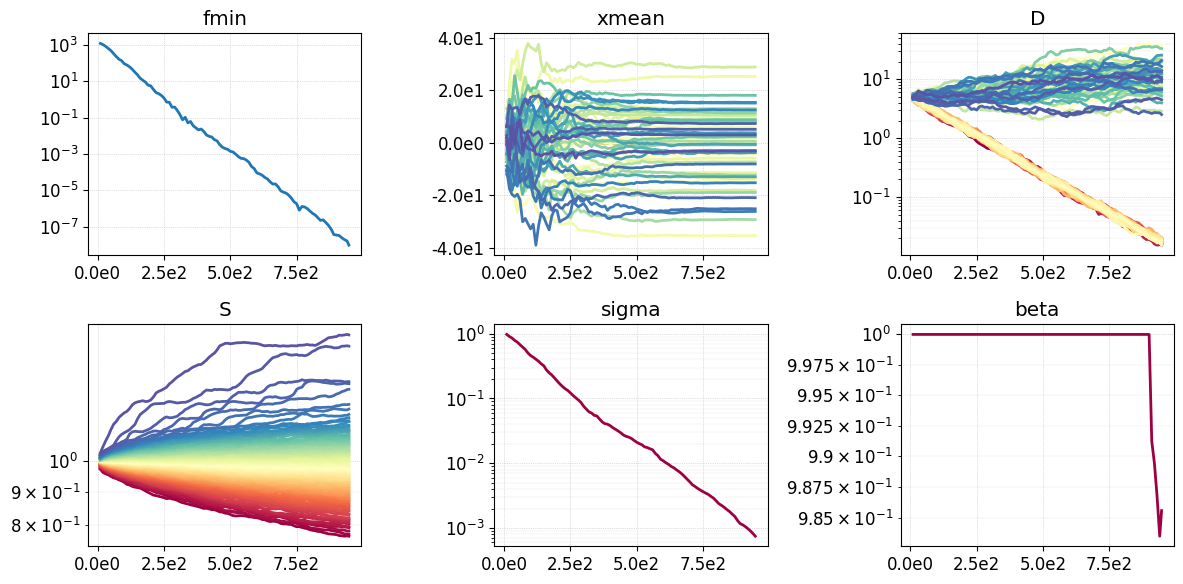

In [5]:
# 実行スクリプト
mode = 0
if mode == 0:
    # 冗長な設計変数
    N = 100
    def subspace_sphere(x):
        dd = 50
        return np.sum(x[:, :dd]**2, axis=1)
elif mode == 1:
    # 冗長な設計変数を取り除いた場合
    N = 50
    def sphere(x):
        return np.sum(x[:, :]**2, axis=1)

xmean0 = 5 * np.random.rand(N)
D0 = 5 * np.ones(N)

# Support for box constraint and periodic variables
# Set np.nan, -np.inf or np.inf if no bound
LOWER_BOUND = -np.inf * np.ones(N)
UPPER_BOUND = np.inf * np.ones(N)
FLAG_PERIODIC = np.asarray([False] * N)
period_length = (UPPER_BOUND - LOWER_BOUND) * 2.0
period_length[FLAG_PERIODIC] /= 2.0
period_length[np.logical_not(np.isfinite(period_length))] = np.inf

def fobj(x):
    xx = mirror(x, LOWER_BOUND, UPPER_BOUND, FLAG_PERIODIC)
    if mode == 0:
        return subspace_sphere(xx)
    else:
        return sphere(xx)

# Setting for resart
NUM_RESTART = 1  # number of restarts with increased population size
MAX_NEVAL = 1e6   # maximal number of f-calls
F_TARGET = 1e-8   # target function value
total_neval = 0   # total number of f-calls

# Main loop
ddcma = DdCma(xmean0=xmean0, sigma0=D0)
ddcma.upper_bounding_coordinate_std(period_length)
checker = Checker(ddcma)
logger = Logger(ddcma)
for restart in range(NUM_RESTART):
    issatisfied = False
    fbestsofar = np.inf
    while not issatisfied:
        ddcma.onestep(func=fobj)
        ddcma.upper_bounding_coordinate_std(period_length)
        fbest = np.min(ddcma.arf)
        fbestsofar = min(fbest, fbestsofar)
        if fbest <= F_TARGET:
            issatisfied, condition = True, 'ftarget'
        else:
            issatisfied, condition = checker()
        if ddcma.t % 10 == 0:
            print(ddcma.t, ddcma.neval, fbest, fbestsofar)
            logger()
    logger(condition)
    print("Terminated with condition: " + str(condition))
    # For restart
    total_neval += ddcma.neval
    if total_neval < MAX_NEVAL and fbest > F_TARGET and restart + 1 < NUM_RESTART:
        popsize = ddcma.lam * 2
        xmean0 = 5 * np.random.rand(N)
        D0 = 5 * np.ones(N)
        ddcma = DdCma(xmean0=xmean0, sigma0=D0, lam=popsize)
        checker = Checker(ddcma)
        logger.setcma(ddcma)
        print("Restart with popsize: " + str(ddcma.lam))
    else:
        break

# Produce a figure
fig, axdict = logger.plot()
for key in axdict:
    if key not in ('xmean'):
        axdict[key].set_yscale('log')
plt.tight_layout()
plt.savefig(logger.prefix + '.pdf')

#### まとめ
- 冗長な変数がある場合，
  - $\sigma$ の減少速度の低下による探索効率の低下
  - 共分散行列の条件数の発散
- 前者の問題は，冗長な変数の割合が少なければほとんど影響は現れないため，現実的な時間で最適化が進んでいれば特に気にする必要はないかもしれません
- 後者の問題は，求めたい設計変数の精度が高く精緻化が必要な場合には，条件数が発散することによる数値誤差の問題が発生し得ます．そのような場合，探索結果として得られた共分散行列を用いて，次元削減することをおすすめします．一例を以下にあげます．

<!-- EN -->
#### Summary
- When redundant variables are present:
  - Reduced search efficiency due to a slower rate of $\sigma$ decrease
  - Divergence of the condition number of the covariance matrix
- The former problem has almost no effect when the proportion of redundant variables is small, so it may not need to be a concern if optimization is progressing within a practical amount of time.
- The latter problem may cause numerical error issues due to the divergence of the condition number when high precision of the desired design variables is needed. In such a case, it is recommended to perform dimensionality reduction using the covariance matrix obtained as the search result. An example is given below.


In [6]:
Cov = ddcma.transform(ddcma.transform(np.eye(ddcma.N)).T)  # 共分散行列を作成
eigval, eigvec = np.linalg.eigh(Cov)  # 固有値分解，eigvec[:, i] が eigval[i] に対応する単位固有ベクトル
print('共分散行列の固有値', eigval)  # 固有値の大きさが大きいもの（冗長な次元）と小さいもの（必要な次元）に分かれていることを確認

N = np.sum(eigval < 1e-8)  # 次元削減後の次元数
xbase = np.copy(ddcma.xmean)  # 前回探索時の平均ベクトルを座標系の原点とする
basis = np.copy(eigvec[:, :N])  # 次元削減後の基底

def reconstruct(x):
    # 次元削減後の（CMA-ESが新たに探索する）設計変数からもとの変数を復元
    return xbase + np.dot(x, basis.T)

共分散行列の固有値 [1.18924806e-10 1.21960026e-10 1.23985521e-10 1.26962292e-10
 1.32507896e-10 1.36485658e-10 1.37217038e-10 1.39437709e-10
 1.43491501e-10 1.44086379e-10 1.46095126e-10 1.49295109e-10
 1.49650604e-10 1.52044842e-10 1.55825911e-10 1.56765692e-10
 1.56978952e-10 1.58753614e-10 1.62040076e-10 1.64024062e-10
 1.64823484e-10 1.67186083e-10 1.68626344e-10 1.69777091e-10
 1.71738311e-10 1.75666524e-10 1.78273097e-10 1.80146380e-10
 1.81063866e-10 1.83279333e-10 1.83858100e-10 1.87009434e-10
 1.90768326e-10 1.92903139e-10 1.94663305e-10 1.96094653e-10
 1.98777283e-10 2.02226008e-10 2.02550148e-10 2.08536248e-10
 2.11854799e-10 2.12905996e-10 2.16647710e-10 2.21824788e-10
 2.25561691e-10 2.30434769e-10 2.34002938e-10 2.35481140e-10
 2.41621311e-10 2.53365885e-10 3.22528317e-06 4.37257157e-06
 8.32607042e-06 1.04836578e-05 1.30837374e-05 1.46906899e-05
 1.84735846e-05 1.88436186e-05 1.95080001e-05 2.14569906e-05
 2.34843161e-05 2.50758712e-05 2.67075738e-05 2.74996105e-05
 2.84034362e-0

10 150 50.55547183050114 30.76666989855317
20 300 30.8844135192327 30.76666989855317
30 450 17.263988041075788 17.263988041075788
40 600 9.104246367151294 9.104246367151294
50 750 6.019853129032206 5.884404154263441
60 900 3.0263493015363423 3.0263493015363423
70 1050 2.582390608592649 2.331756014528834
80 1200 1.4570729274955432 1.304410787047249
90 1350 1.061200607855981 0.9568953042597699
100 1500 0.5702850883495243 0.4957573636701349
110 1650 0.25565219318694976 0.25565219318694976
120 1800 0.10978567720467498 0.10978567720467498
130 1950 0.07871032939430282 0.07871032939430282
140 2100 0.033507412955885184 0.03102860694225278
150 2250 0.016991127494652543 0.016991127494652543
160 2400 0.008237065675086405 0.008237065675086405
170 2550 0.006252805093668494 0.006190634820225693
180 2700 0.0025628151125745373 0.0025628151125745373
190 2850 0.0012693060013636657 0.0012693060013636657
200 3000 0.0005714145165192744 0.0005714145165192744
210 3150 0.0003959290060111391 0.0003775838799953

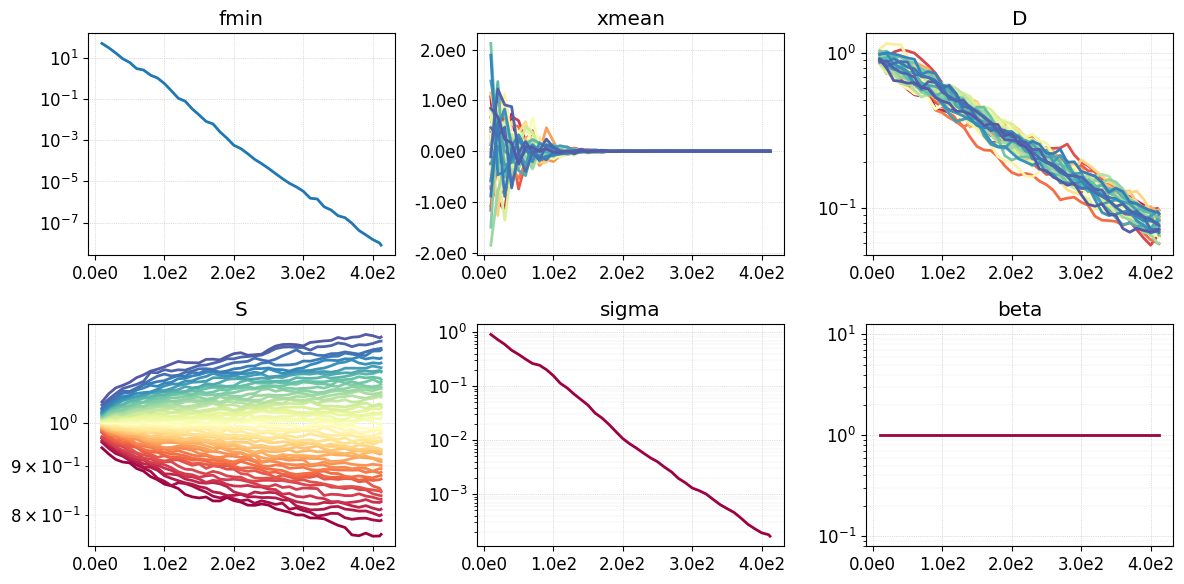

In [7]:
# 実行スクリプト
xmean0 = np.zeros(N)  # 原点が前回探索した解なので，その周辺から始めることがおすすめ
D0 = np.ones(N)

# Support for box constraint and periodic variables
# Set np.nan, -np.inf or np.inf if no bound
LOWER_BOUND = -np.inf * np.ones(N)
UPPER_BOUND = np.inf * np.ones(N)
FLAG_PERIODIC = np.asarray([False] * N)
period_length = (UPPER_BOUND - LOWER_BOUND) * 2.0
period_length[FLAG_PERIODIC] /= 2.0
period_length[np.logical_not(np.isfinite(period_length))] = np.inf

def fobj(x):
    xx = mirror(x, LOWER_BOUND, UPPER_BOUND, FLAG_PERIODIC)
    return subspace_sphere(reconstruct(xx))  # CMA-ESが探索する空間は次元削減後の空間なので，目的関数にわたすときには reconstruct

# Setting for resart
NUM_RESTART = 1  # number of restarts with increased population size
MAX_NEVAL = 1e6   # maximal number of f-calls
F_TARGET = 1e-8   # target function value
total_neval = 0   # total number of f-calls

# Main loop
ddcma = DdCma(xmean0=xmean0, sigma0=D0)
ddcma.upper_bounding_coordinate_std(period_length)
checker = Checker(ddcma)
logger = Logger(ddcma)
for restart in range(NUM_RESTART):
    issatisfied = False
    fbestsofar = np.inf
    while not issatisfied:
        ddcma.onestep(func=fobj)
        ddcma.upper_bounding_coordinate_std(period_length)
        fbest = np.min(ddcma.arf)
        fbestsofar = min(fbest, fbestsofar)
        if fbest <= F_TARGET:
            issatisfied, condition = True, 'ftarget'
        else:
            issatisfied, condition = checker()
        if ddcma.t % 10 == 0:
            print(ddcma.t, ddcma.neval, fbest, fbestsofar)
            logger()
    logger(condition)
    print("Terminated with condition: " + str(condition))
    # For restart
    total_neval += ddcma.neval
    if total_neval < MAX_NEVAL and fbest > F_TARGET and restart + 1 < NUM_RESTART:
        popsize = ddcma.lam * 2
        xmean0 = 5 * np.random.rand(N)
        D0 = 5 * np.ones(N)
        ddcma = DdCma(xmean0=xmean0, sigma0=D0, lam=popsize)
        checker = Checker(ddcma)
        logger.setcma(ddcma)
        print("Restart with popsize: " + str(ddcma.lam))
    else:
        break

# Produce a figure
fig, axdict = logger.plot()
for key in axdict:
    if key not in ('xmean'):
        axdict[key].set_yscale('log')
plt.tight_layout()
plt.savefig(logger.prefix + '.pdf')


## 3. 尖った等高線を持つ目的関数



CMA-ESは勾配を利用せず，また目的関数の値も直接は使用しないため，微分可能かどうかが直接は探索のしやすさに影響しません．例えば，なめらかな関数を単調増加変換した関数はなめらかになる保証はなく，勾配も定義されない可能性がありませんが，CMA-ESにとってはなめらかな関数と同等に扱われます．なめらかな関数の単調変換で表されるような関数は，等高線がなめらかになります．

一方，等高線が尖った目的関数の場合には，注意が必要です．
例えば，
$$
f(x) = \sum_{i=1}^{d} |x_i|
$$
という関数は，$x_i = 0$となる任意の点において，等高線が尖っていることが容易にわかります．これを一般化したものとして，
$$
f(x) = \left(\sum_{i=1}^{d} |x_i|^{p}\right)^{1/p}
$$
なども考えられます．$p$が小さい値になると，より尖った等高線となります．

等高線が尖っていても，その角度が0でなければ（例えば$p = 1$のケース），うまく探索できるでしょう．しかし，その角度が0になるケースでは，失敗する場合があります．

#### 確認事項
- $p = 1/4$のとき，デフォルトの集団サイズでは最適解でない微分不能な点に早期収束してしまう
- 集団サイズを増加させることで緩和することは可能

<!-- EN -->
## 3. Objective Functions with Sharp Contours


<!-- EN -->

Since CMA-ES does not use gradients and does not directly use objective function values, whether a function is differentiable does not directly affect the ease of search. For example, a function obtained by applying a monotonically increasing transformation to a smooth function is not guaranteed to be smooth and may not have a well-defined gradient, but CMA-ES treats it equivalently to a smooth function. Functions expressible as monotonic transformations of smooth functions have smooth contours.

On the other hand, care is needed for objective functions with sharp contours.
For example, the function
$$
f(x) = \sum_{i=1}^{d} |x_i|
$$
can easily be seen to have sharp contours at any point where $x_i = 0$. As a generalization of this,
$$
f(x) = \left(\sum_{i=1}^{d} |x_i|^{p}\right)^{1/p}
$$
can also be considered. When $p$ is small, the contours become sharper.

Even if contours are sharp, if the angle is not zero (e.g., the $p = 1$ case), the search can proceed well. However, when the angle becomes zero, failure may occur.

#### Items to verify
- When $p = 1/4$, the default population size causes premature convergence to a non-optimal point of non-differentiability.
- Increasing the population size can mitigate this.


10 100 6228.137705183568 5779.349620473056
20 200 7676.1596961347495 5224.747714738184
30 300 5723.442318272635 2183.9743654739464
40 400 4734.597184311761 2183.9743654739464
50 500 1599.5577870747395 1599.5577870747395
60 600 1668.6020495408266 1195.0499814234531
70 700 823.5550440765664 786.4742364345968
80 800 526.9393354453167 432.59114645648737
90 900 368.11030411554526 215.7174614719356
100 1000 138.1684338667192 127.22884848839183
110 1100 83.94611427082063 82.41241717310652
120 1200 72.59146481179056 55.68877133966722
130 1300 26.25584399625261 26.25584399625261
140 1400 14.50925895022141 14.50925895022141
150 1500 7.451515094024928 6.069147528919554
160 1600 5.399479146352264 4.214198017492124
170 1700 2.230979740671695 2.0872158957226703
180 1800 1.046880813812931 0.8045541044742678
190 1900 0.49109375322470605 0.1828925388732921
200 2000 0.26683543373624335 0.12570984628916576
210 2100 0.18098375797280525 0.1045955295900594
220 2200 0.08967695617938955 0.06944087516562099
23

/content/ddcma.py:267: RuntimeWarning: assumed no tie, but there exists
  warnings.warn("assumed no tie, but there exists", RuntimeWarning)


740 7400 7.685797776527388e-07 7.474642220728355e-07
750 7500 7.474110308436366e-07 7.474110308436366e-07
760 7600 7.473515557521182e-07 7.473391923085161e-07
770 7700 7.47213016794035e-07 7.47213016794035e-07
780 7800 7.471083653953767e-07 7.471063572239699e-07
790 7900 7.469622627098714e-07 7.469622627098714e-07
800 8000 7.468436056257133e-07 7.468436056257133e-07
810 8100 7.467088805057642e-07 7.466858509275197e-07
820 8200 7.465769416015179e-07 7.465769416015179e-07
830 8300 7.464081512864593e-07 7.464081512864593e-07
840 8400 7.462952460457474e-07 7.462952460457474e-07
850 8500 7.461873261505049e-07 7.461450293178019e-07
860 8600 7.460947353266081e-07 7.460626676447645e-07
870 8700 7.459069557569365e-07 7.459069557569365e-07
880 8800 7.458052362352419e-07 7.458052362352419e-07
890 8900 7.456721675680456e-07 7.456672035388576e-07
900 9000 7.455553445723239e-07 7.455514969834097e-07
910 9100 7.454773456316844e-07 7.454668091710914e-07
920 9200 7.454527484185293e-07 7.453966928139267

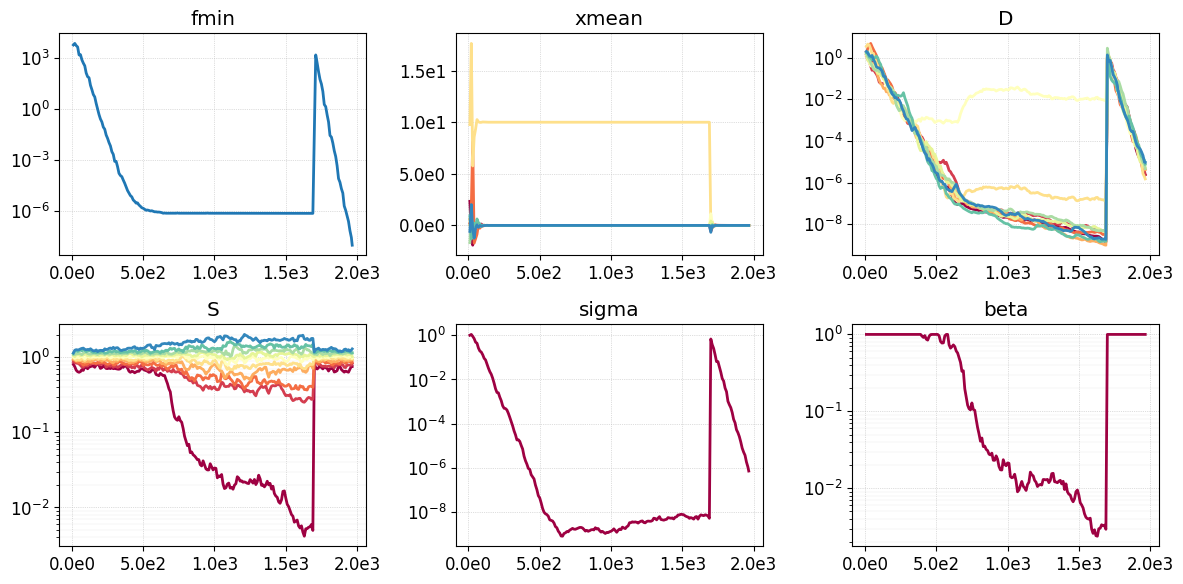

In [8]:
# 実行スクリプト
N = 10

def pnorm(x):
    p = 1/4  # ここを変更して実行
    f = np.sum(np.abs(x)**p, axis=1)**(1/p)
    return f

# Support for box constraint and periodic variables
# Set np.nan, -np.inf or np.inf if no bound
LOWER_BOUND = -5.0 * np.ones(N)
UPPER_BOUND = 5.0 * np.ones(N)
FLAG_PERIODIC = np.asarray([False] * N)
period_length = (UPPER_BOUND - LOWER_BOUND) * 2.0
period_length[FLAG_PERIODIC] /= 2.0
period_length[np.logical_not(np.isfinite(period_length))] = np.inf

def fobj(x):
    xx = mirror(x, LOWER_BOUND, UPPER_BOUND, FLAG_PERIODIC)
    return pnorm(xx)

# Setting for resart
NUM_RESTART = 10  # number of restarts with increased population size
MAX_NEVAL = 1e6   # maximal number of f-calls
F_TARGET = 1e-8   # target function value
total_neval = 0   # total number of f-calls

# Main loop
ddcma = DdCma(xmean0=np.random.randn(N), sigma0=np.ones(N)*2.)
ddcma.upper_bounding_coordinate_std(period_length)
checker = Checker(ddcma)
logger = Logger(ddcma)
for restart in range(NUM_RESTART):
    issatisfied = False
    fbestsofar = np.inf
    while not issatisfied:
        ddcma.onestep(func=fobj)
        ddcma.upper_bounding_coordinate_std(period_length)
        fbest = np.min(ddcma.arf)
        fbestsofar = min(fbest, fbestsofar)
        if fbest <= F_TARGET:
            issatisfied, condition = True, 'ftarget'
        else:
            issatisfied, condition = checker()
        if ddcma.t % 10 == 0:
            print(ddcma.t, ddcma.neval, fbest, fbestsofar)
            logger()
    logger(condition)
    print("Terminated with condition: " + str(condition))
    # For restart
    total_neval += ddcma.neval
    if total_neval < MAX_NEVAL and fbest > F_TARGET and restart + 1 < NUM_RESTART:
        popsize = ddcma.lam * 2
        ddcma = DdCma(xmean0=np.random.randn(N), sigma0=np.ones(N)*2., lam=popsize)
        checker = Checker(ddcma)
        logger.setcma(ddcma)
        print("Restart with popsize: " + str(ddcma.lam))
    else:
        break

# Produce a figure
fig, axdict = logger.plot()
for key in axdict:
    if key not in ('xmean'):
        axdict[key].set_yscale('log')
plt.tight_layout()
plt.savefig(logger.prefix + '.pdf')

#### まとめと対策
- 尖った等高線を持つ目的関数では探索に失敗することがある．特に，開き角度が$0$になるケースは注意．
- 多少の尖ったケースであれば，集団サイズを大きくすることで，対応可能です．集団サイズを大きくしながらリスタートする戦略を取っていれば，問題なく対応できる場合があります．ただし，定式化の段階で対応するに越したことはありません．
- 尖った等高線を持つ目的関数は，max や min，条件分岐がある場合に起こりやすい．可能であれば，max をなめらかな関数で近似するなどの工夫をしましょう．例えば，maxであればLogSumExp関数（$a > 0$）
$$
z_{\max} = \max(z_1, \dots, z_k) \approx \frac{1}{a} \log\left(\sum_{i=1}^{k} \exp(a z_i)\right) = z_{\max} + \frac{1}{a} \log\left(\sum_{i=1}^{k} \exp(a (z_i - z_\max))\right)
$$
であったり，Softmax関数を用いる方法が考えられます．
- 制約条件をペナルティ関数を用いて対処する場合も，尖った等高線を作り出しやすいので，注意が必要です．例えば，ある関数$g(x)$が$G$を超えてほしくない場合，$f(x) + c \max(g(x) - G, 0)$（$c$はペナルティ係数）といった方法がよく採用されますが，この場合も制約の境界上がなめらかでなくなる可能性があります．境界上の目的関数値が最適でない場合には，問題になりませんが，最適であるため境界上に収束することが必要になる場合には気をつけましょう．



<!-- EN -->
#### Summary and countermeasures
- Objective functions with sharp contours may cause search failure. In particular, cases where the opening angle becomes $0$ require attention.
- For moderately sharp cases, increasing the population size can handle the problem. If you use a strategy of restarting while increasing the population size, you may be able to handle the problem without issues. However, it is even better to address the issue at the formulation stage.
- Objective functions with sharp contours tend to arise when there are max, min, or conditional branches. If possible, try approximating max with a smooth function. For example, for max, the LogSumExp function ($a > 0$)
$$
z_{\max} = \max(z_1, \dots, z_k) \approx \frac{1}{a} \log\left(\sum_{i=1}^{k} \exp(a z_i)\right) = z_{\max} + \frac{1}{a} \log\left(\sum_{i=1}^{k} \exp(a (z_i - z_\max))\right)
$$
or the Softmax function can be used.
- When dealing with constraints using penalty functions, sharp contours are also easily created, so care is needed. For example, when a function $g(x)$ should not exceed $G$, a method such as $f(x) + c \max(g(x) - G, 0)$ (where $c$ is a penalty coefficient) is often adopted, but in this case too, the boundary of the constraint may become non-smooth. If the optimal objective function value is not at the boundary, this is not a problem, but care must be taken when it is necessary to converge to the boundary because the optimal solution lies there.


## 4. 大域的多峰な目的関数



前述の通り，大域的多峰性を持つ関数の場合，最適化アルゴリズムサイドからアプローチしようとしても，集団サイズを大きくしても効果が無い，もしくは逆効果，となるため，初期値を変えながらリスタートを繰り返す力技に頼らざるを得ません．

この場合，目的関数の設計を工夫することで，回避できる場合もあります．例えば，目的関数とは別にある関数$g(x)$が存在し，望ましい解であれば$g(x)$の値も小さくなるはずである，という事前知識がある場合，これが活用できます．例えば，$f(x) + c g(x)$（$c > 0$）などとし，$c$をうまく調整することで，大域的最適な解へと誘導することができる場合もあります．

例えば，前述のdouble-Sphere関数を考えましょう．最適解の座標は各次元$a > 0$，もう一つの局所解の座標は各次元$b < 0$ となっていました．例えば事前知識として，$g(x) = \sum_{i=1}^{d}(x_i - 1)^2$が小さい解が望ましいといった情報を持っているとしましょう．このとき，上のように目的関数を変更することで，$g(x)$の値が小さくなるような解へと誘導することができます．ただし，そのようにして得られた解は，必ずしも$f(x)$の（局所）最適解ではないため，得られた解を初期解として，$f(x)$を局所探索すると良いでしょう．

#### 確認事項
Double-Sphere 関数を用いて
- 適切な関数$g$を用いることで，大域的最適解の谷へと誘導できること
- 得られた解を用いて局所探索することで，$f$の最適解が得られること

<!-- EN -->
## 4. Globally Multimodal Objective Functions


<!-- EN -->


As mentioned above, for functions with global multimodality, even from the algorithm side, increasing the population size has no effect or is counterproductive, so one has no choice but to rely on the brute-force approach of repeatedly restarting with different initial values.

In some cases, this can be circumvented by devising the objective function design. For example, if there exists a function $g(x)$ separate from the objective function, and there is prior knowledge that if a solution is desirable then $g(x)$ should also be small, this can be exploited. For example, by forming $f(x) + c g(x)$ ($c > 0$) and adjusting $c$ appropriately, it may be possible to guide the search toward the globally optimal solution.

For example, consider the Double-Sphere function mentioned earlier. The coordinates of the optimal solution were $a > 0$ in each dimension, and the coordinates of the other local optimum were $b < 0$ in each dimension. Suppose, for example, that prior knowledge indicates that solutions with small values of $g(x) = \sum_{i=1}^{d}(x_i - 1)^2$ are desirable. By modifying the objective function as above, one can guide the search toward solutions with smaller values of $g(x)$. However, since the solution obtained in this way is not necessarily a (local) optimal solution of $f(x)$, it is advisable to use the obtained solution as the initial solution for a local search of $f(x)$.

#### Items to verify
Using the Double-Sphere function:
- Confirm that using an appropriate function $g$ can guide the search toward the valley of the global optimum.
- Confirm that by performing local search using the obtained solution, the optimal solution of $f$ can be obtained.


10 100 79.05075697527502 47.72511634745873
20 200 17.151929777649606 17.151929777649606
30 300 14.21729101216715 12.585257043205413
40 400 12.658135331322839 12.20388687094351
50 500 11.320744141363086 11.320744141363086
60 600 11.256524195058361 11.256524195058361
70 700 11.252559917551604 11.252169861636105
80 800 11.250412971179543 11.250412971179543
90 900 11.250150883198359 11.25006546578139
100 1000 11.25004059349842 11.250014666025908
110 1100 11.25000494024661 11.25000494024661
120 1200 11.250000815387319 11.250000815387319
130 1300 11.250000213127901 11.250000133195757
140 1400 11.250000013737385 11.250000013737385
150 1500 11.25000000725015 11.250000004291149
160 1600 11.250000001150966 11.250000001150966
170 1700 11.250000000267967 11.250000000233287
180 1800 11.250000000026514 11.250000000026514
190 1900 11.250000000008082 11.250000000006157
200 2000 11.250000000002528 11.250000000002528
210 2100 11.250000000000218 11.250000000000218
220 2200 11.250000000000032 11.250000000

/content/ddcma.py:267: RuntimeWarning: assumed no tie, but there exists
  warnings.warn("assumed no tie, but there exists", RuntimeWarning)


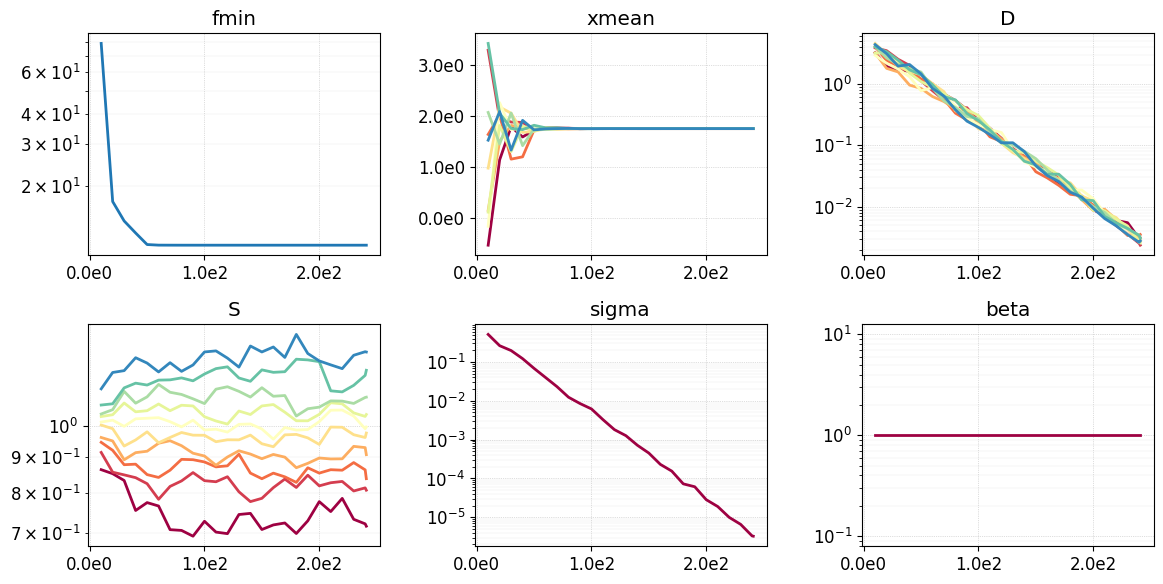

In [9]:
# 実行スクリプト
N = 10
xmean0 = np.zeros(N)
D0 = 5.0 * np.ones(N)
lam = 10

def doublesphere(x):
    s = 0.2
    a = 2.5
    b = - np.sqrt((a**2 - 1) / s)
    f1 = np.sum((x[:, :] - a)**2, axis=1)
    f2 = N + s * np.sum((x[:, :] - b)**2, axis=1)
    return np.fmin(f1, f2)

def g(x):
    return np.mean((x - 1.0)**2, axis=1)

# Support for box constraint and periodic variables
# Set np.nan, -np.inf or np.inf if no bound
LOWER_BOUND = - np.inf * np.ones(N)
UPPER_BOUND = np.inf * np.ones(N)
FLAG_PERIODIC = np.asarray([False] * N)
period_length = (UPPER_BOUND - LOWER_BOUND) * 2.0
period_length[FLAG_PERIODIC] /= 2.0
period_length[np.logical_not(np.isfinite(period_length))] = np.inf

def fobj(x):
    xx = mirror(x, LOWER_BOUND, UPPER_BOUND, FLAG_PERIODIC)
    return doublesphere(xx) + 1e1 * g(xx)  # ガイドを追加

# Setting for resart
NUM_RESTART = 1  # number of restarts with increased population size
MAX_NEVAL = 1e6   # maximal number of f-calls
F_TARGET = 1e-8   # target function value
total_neval = 0   # total number of f-calls

# Main loop
ddcma = DdCma(xmean0=xmean0, sigma0=D0, lam=lam)
ddcma.upper_bounding_coordinate_std(period_length)
checker = Checker(ddcma)
logger = Logger(ddcma)
for restart in range(NUM_RESTART):
    issatisfied = False
    fbestsofar = np.inf
    while not issatisfied:
        ddcma.onestep(func=fobj)
        ddcma.upper_bounding_coordinate_std(period_length)
        fbest = np.min(ddcma.arf)
        fbestsofar = min(fbest, fbestsofar)
        if fbest <= F_TARGET:
            issatisfied, condition = True, 'ftarget'
        else:
            issatisfied, condition = checker()
        if ddcma.t % 10 == 0:
            print(ddcma.t, ddcma.neval, fbest, fbestsofar)
            logger()
    logger(condition)
    print("Terminated with condition: " + str(condition))
    # For restart
    total_neval += ddcma.neval
    if total_neval < MAX_NEVAL and fbest > F_TARGET and restart + 1 < NUM_RESTART:
        popsize = ddcma.lam * 2
        ddcma = DdCma(xmean0=np.random.randn(N), sigma0=np.ones(N)*2., lam=popsize)
        checker = Checker(ddcma)
        logger.setcma(ddcma)
        print("Restart with popsize: " + str(ddcma.lam))
    else:
        break

# Produce a figure
fig, axdict = logger.plot()
for key in axdict:
    if key not in ('xmean'):
        axdict[key].set_yscale('log')
plt.tight_layout()
plt.savefig(logger.prefix + '.pdf')

In [10]:
xmean0 = np.copy(ddcma.xmean)
print(xmean0, doublesphere(xmean0.reshape((1, -1))))

[1.75000001 1.75       1.74999999 1.74999999 1.75000001 1.75
 1.74999999 1.74999999 1.75000001 1.75      ] [5.62500002]


10 100 1.3939744588903575 1.3939744588903575
20 200 0.47450216471102497 0.4340045260596585
30 300 0.16572551736288585 0.14300333768020645
40 400 0.030328606280533372 0.022672666808649176
50 500 0.0055290379740790116 0.004108412219060892
60 600 0.0014985209499610236 0.0008390133882843596
70 700 9.818698625006161e-05 9.818698625006161e-05
80 800 2.1556601184765234e-05 2.134770205079827e-05
90 900 5.536304275837473e-06 3.767174594872018e-06
100 1000 7.749539476166272e-07 7.749539476166272e-07
110 1100 1.5953893328182113e-07 1.5953893328182113e-07
120 1200 3.758810814073795e-08 3.758810814073795e-08
Terminated with condition: ftarget


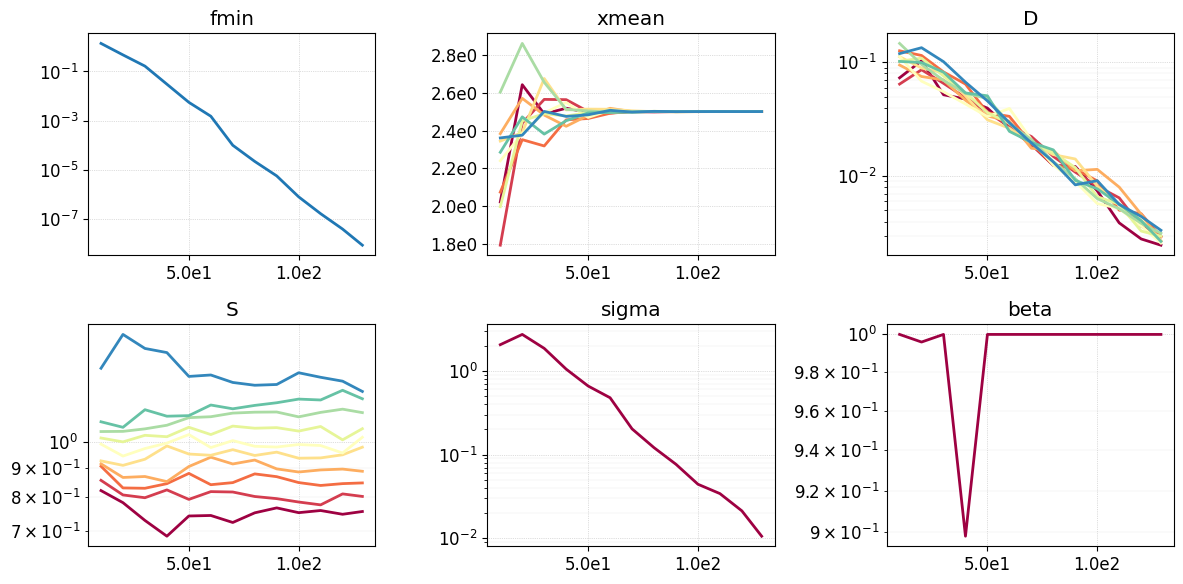

In [11]:
# 実行スクリプト
N = 10
D0 = 0.1 * np.ones(N)  # 上のようにして最適化して得られた平均ベクトルを初期解として局所探索
lam = 10

# Support for box constraint and periodic variables
# Set np.nan, -np.inf or np.inf if no bound
LOWER_BOUND = - np.inf * np.ones(N)
UPPER_BOUND = np.inf * np.ones(N)
FLAG_PERIODIC = np.asarray([False] * N)
period_length = (UPPER_BOUND - LOWER_BOUND) * 2.0
period_length[FLAG_PERIODIC] /= 2.0
period_length[np.logical_not(np.isfinite(period_length))] = np.inf

def fobj(x):
    xx = mirror(x, LOWER_BOUND, UPPER_BOUND, FLAG_PERIODIC)
    return doublesphere(xx)

# Setting for resart
NUM_RESTART = 1  # number of restarts with increased population size
MAX_NEVAL = 1e6   # maximal number of f-calls
F_TARGET = 1e-8   # target function value
total_neval = 0   # total number of f-calls

# Main loop
ddcma = DdCma(xmean0=xmean0, sigma0=D0, lam=lam)
ddcma.upper_bounding_coordinate_std(period_length)
checker = Checker(ddcma)
logger = Logger(ddcma)
for restart in range(NUM_RESTART):
    issatisfied = False
    fbestsofar = np.inf
    while not issatisfied:
        ddcma.onestep(func=fobj)
        ddcma.upper_bounding_coordinate_std(period_length)
        fbest = np.min(ddcma.arf)
        fbestsofar = min(fbest, fbestsofar)
        if fbest <= F_TARGET:
            issatisfied, condition = True, 'ftarget'
        else:
            issatisfied, condition = checker()
        if ddcma.t % 10 == 0:
            print(ddcma.t, ddcma.neval, fbest, fbestsofar)
            logger()
    logger(condition)
    print("Terminated with condition: " + str(condition))
    # For restart
    total_neval += ddcma.neval
    if total_neval < MAX_NEVAL and fbest > F_TARGET and restart + 1 < NUM_RESTART:
        popsize = ddcma.lam * 2
        ddcma = DdCma(xmean0=np.random.randn(N), sigma0=np.ones(N)*2., lam=popsize)
        checker = Checker(ddcma)
        logger.setcma(ddcma)
        print("Restart with popsize: " + str(ddcma.lam))
    else:
        break

# Produce a figure
fig, axdict = logger.plot()
for key in axdict:
    if key not in ('xmean'):
        axdict[key].set_yscale('log')
plt.tight_layout()
plt.savefig(logger.prefix + '.pdf')

## その他のトピック


<!-- EN -->
## Other Topics



#### 制約条件の対処
制約と一言でいっても，使える情報や計算時間など，状況は多岐に渡ります．矩形制約などは標準的に対応されている場合が多いものの，それ以外の制約はペナルティ関数を使うなどが一般的に利用しやすいでしょう．ただし，ペナルティ係数の設定によっては非常に解きにくい問題になってしまう，最適解が制約を違反してしまう，などの困難さがつきまといます．制約条件の性質毎に適切な制約対処法が異なるため，性質を良く検討した上で制約対処法を選択しましょう．

#### シミュレーション条件の不確実性
目的関数は基本的にシミュレーションを通して計算されると想定していますが，シミュレーションの条件が予め一意に定まるとは限りません．例えば，タイヤの設計をしている場合，路面状態によってグリップ性能は変わるでしょう．その場合，特定の状況を想定して最適化しても，他の状況では良くない解を得てしまう可能性があります．また，現実環境の情報が不足しているため，シミュレーション条件がそもそも不確実である，という場面も想定されます．その場合，考え得る最悪ケースの性能を最適化する，などの方法があります．シミュレーション環境が不確実な場合には，そのようなロバスト最適化などを検討しましょう．

#### 実行時間
目的関数の評価回数（シミュレーション回数）が少ない場合，CMA-ESよりもNelder-Mead法などを用いた局所探索をしたほうが，良い解を得られる場合があることを述べました．しかし，目的関数の評価回数が少なければ，あくまで局所的な探索しかできないことも事実です．大域的な探索を行いたい場合，シミュレーションの精度を落として高速に計算できるようにする方法が考えられます．ただ，愚直にこれを実装すると，シミュレーション精度が悪いので探索結果の信頼性が損なわれます．これに対して，シミュレーション精度をコントロールしながら最適化を進めていく，マルチフィデリティ最適化，という方針があります．シミュレーション時間がネックでありCMA-ESを活用できない場合には，この方針を検討してみましょう．

<!-- EN -->

#### Constraint handling
Even when we use the word "constraint," the available information and computation time vary widely. Box constraints are often handled as standard, but for other types of constraints, using penalty functions is generally the most accessible approach. However, difficulties arise such as the problem becoming very hard to solve depending on the penalty coefficient setting, or the optimal solution violating the constraint. Since the appropriate constraint handling method differs depending on the nature of the constraints, carefully examine the properties and select an appropriate constraint handling method.

#### Uncertainty in simulation conditions
It is assumed that the objective function is basically computed through simulation, but the simulation conditions are not always uniquely determined in advance. For example, when designing a tire, grip performance varies depending on road surface conditions. In that case, even if optimization is performed assuming a specific situation, there is a possibility of obtaining a poor solution in other situations. Also, situations can be imagined where simulation conditions are inherently uncertain due to insufficient information about the real environment. In that case, there are methods such as optimizing the worst-case performance. When the simulation environment is uncertain, consider such robust optimization.

#### Runtime
We noted that when the number of objective function evaluations (number of simulations) is small, local search using the Nelder-Mead method may yield a better solution than CMA-ES. However, it is also true that when the number of objective function evaluations is small, only local search is possible. When global search is desired, a method of reducing simulation accuracy to enable faster computation can be considered. However, implementing this naively undermines the reliability of the search results due to poor simulation accuracy. In response to this, there is an approach called multi-fidelity optimization, which proceeds with optimization while controlling simulation accuracy. When simulation time is a bottleneck and CMA-ES cannot be utilized effectively, consider this approach.


# おわりに

<!-- EN -->
# Conclusion


この資料がCMA-ESの利用者にとって少しでもCMA-ESをうまく活用する糧になればと思いますが，実応用上の困難さは多岐に渡るため，カバーしきれていないトピックも多くあります．どうしてもうまく行かないという場合には，秋本までご相談ください．

<!-- EN -->
I hope this material will be of some help to CMA-ES users in making better use of CMA-ES, but since the difficulties in practical applications are diverse, there are many topics not covered. If you find that things simply do not work out, please feel free to consult Akimoto.
